# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [6]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [6]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` debe cambiar el tipo de dato de "float64" a "int64" porque es un número entero.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [7]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [8]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [9]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Se realizó un análisis descriptivo de las variables numéricas del conjunto de datos para conocer su comportamiento general, identificar posibles valores atípicos y evaluar la dispersión de los datos.

- `edad`: Los clientes tienen entre 18 y 75 años, con una edad promedio de 38.3 años y una mediana de 38 años, lo que indica una distribución relativamente simétrica. La desviación estándar de 11.5 años refleja una variabilidad moderada.
- `Nivel de ingreso`: El ingreso mensual presenta un promedio de 30,019.70, con valores entre 8,000 y 74,790.84. La media y la mediana son prácticamente iguales, lo que sugiere una distribución cercana a la simetría. Sin embargo, el valor máximo es considerablemente superior al tercer cuartil (36,768.44), por lo que podrían existir algunos valores altos que conviene revisar mediante gráficos.
- `Visitas por mes`: Los clientes realizan en promedio 10 visitas mensuales, con un rango de 1 a 25 visitas. La media y la mediana coinciden prácticamente, indicando una distribución equilibrada y sin evidencia clara de sesgo.
- `Compras por mes`: El promedio es de 1.21 compras mensuales, mientras que la mediana es 1 compra. Aunque la mayoría de los clientes realiza pocas compras (el 75% realiza hasta 2 compras al mes), existen casos de hasta 8 compras, lo que podría indicar una ligera asimetría hacia valores altos.
- `Gasto en publicidad dirigida`: El gasto promedio es de 20.15, con valores entre 0 y 75.51. La desviación estándar (10.88) muestra una dispersión considerable y el máximo es muy superior al tercer cuartil (27.29), por lo que es recomendable evaluar la presencia de valores atípicos.
- `Satisfacción`: La calificación de satisfacción varía entre 1 y 5, con un promedio de 3.60 y una mediana de 3.6, indicando que, en general, los clientes presentan un nivel de satisfacción moderadamente alto y una distribución bastante equilibrada.
- `Ingreso anual`: Esta variable presenta la mayor dispersión del conjunto, con valores entre 0 y 244.69 y una desviación estándar de 34.48. Además, el primer cuartil es 0, lo que indica que al menos el 25% de los registros tiene un ingreso anual igual a cero. La diferencia entre la media (36.59) y la mediana (30.71), junto con el valor máximo muy superior al tercer cuartil (58.22), sugiere una distribución sesgada hacia la derecha y la posible presencia de valores extremos.

#### Explorar variables binarias

In [10]:
# Verificar que cada columna tenga únicamente dos valores posibles
for col in ['miembro_premium', 'abandono']:
    print(col)
    print(df[col].unique())

miembro_premium
[0 1]
abandono
[0 1]


✍️ **Comentario**: Se verificó que las variables `miembro_premium` y `abandono` contienen únicamente dos valores posibles (0 y 1), por lo que ambas representan correctamente variables binarias y no presentan categorías inesperadas o errores de codificación.

Además, a partir de la estadística descriptiva se puede interpretar la proporción de cada categoría:

- `Miembro premium`: La media es 0.1393, lo que indica que aproximadamente el 13.9% de los clientes son miembros premium, mientras que el 86.1% no lo son.
- `Abandono`: La media es 0.1507, lo que significa que alrededor del 15.1% de los clientes abandonaron el servicio, mientras que el 84.9% permanecieron como clientes.

En ambos casos existe un desbalance moderado entre las clases, ya que la categoría 0 es considerablemente más frecuente que la categoría 1. Este aspecto debe tenerse en cuenta si posteriormente se desarrolla un modelo de clasificación, ya que podría influir en su desempeño.

#### Explorar variables categóricas

In [13]:
# Verificar el número de valores únicos por variable categórica
for col in ['tipo_dispositivo', 'region']:
    print(col)
    print(df[col].unique())

tipo_dispositivo
['móvil' 'tablet' 'escritorio']
region
['norte' 'sur' 'este' 'oeste']


In [18]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(df[col].value_counts(normalize=True))

móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64


✍️ **Comentario**: Se analizaron las variables categóricas mediante tablas de frecuencia para conocer cómo se distribuyen los clientes en cada categoría e identificar posibles desbalances.

- `tipo_dispositivo`: Se observó la distribución de clientes entre las categorías móvil, escritorio y tablet. El análisis permitió identificar que el móvil es el dispositivo más usado, con un porcentaje del 65.45% del total, lo cual es considerablemente mayor al escritorio (24.8%) y tablet (9.75%).
- `region`: Se evaluó la distribución de clientes entre las regiones norte, sur, este y oeste. La distribución geográfica es relativamente equilibrada. La región norte concentra el mayor porcentaje de clientes (29.30%), seguida de oeste (25.40%), sur (24.84%) y este (20.46%). Aunque existen pequeñas diferencias entre regiones, ninguna presenta una representación extremadamente baja o alta.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

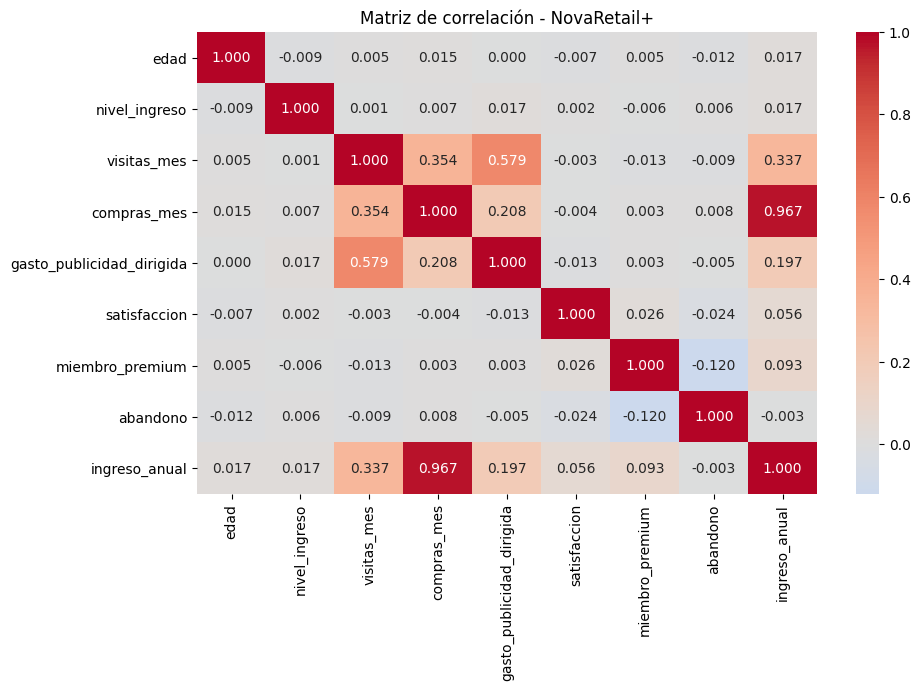

In [24]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', center=0)
plt.title('Matriz de correlación - NovaRetail+')
plt.show()

✍️ **Comentario**:
Observaciones generales (Heatmap):
- La mayoría de las variables presentan correlaciones muy bajas o cercanas a cero, lo que indica que no existe una relación lineal fuerte entre ellas. Variables como edad, nivel_ingreso, satisfacción, miembro_premium y abandono muestran una asociación prácticamente nula con el resto de las variables.
- Se observa una correlación positiva moderada (0.579) entre visitas_mes y gasto_publicidad_dirigida, lo que sugiere que los clientes que reciben una mayor inversión en publicidad tienden a visitar la plataforma con mayor frecuencia.
- También existe una correlación positiva moderada (0.354) entre visitas_mes y compras_mes, lo que indica que un mayor número de visitas suele asociarse con un mayor número de compras.
- La variable miembro_premium presenta una correlación negativa débil (-0.120) con abandono, lo que sugiere que los clientes con membresía premium tienen una ligera tendencia a abandonar menos la plataforma. Sin embargo, la relación es débil.


Observaciones respecto a `ingreso_anual`:
- La variable con la mayor correlación es `compras_mes` (0.967). Esta es una correlación positiva muy fuerte, lo que indica que el ingreso anual de la empresa aumenta considerablemente conforme aumenta el número de compras realizadas por los clientes. Es la relación más relevante del conjunto de datos.
- `visitas_mes` presenta una correlación positiva moderada (0.337) con el `ingreso anual`. Esto sugiere que los clientes que visitan con mayor frecuencia la plataforma tienden a generar mayores ingresos, aunque la relación es mucho menor que la observada con el número de compras.
- `gasto_publicidad_dirigida` muestra una correlación positiva débil (0.197). Esto podría indicar que una mayor inversión publicitaria se asocia con un ligero incremento en el ingreso anual, aunque el efecto no parece ser determinante por sí solo.
- `miembro_premium` (0.093) y `satisfacción` (0.056) presentan correlaciones positivas muy débiles con el ingreso anual, por lo que su relación lineal es prácticamente insignificante.
- Las variables `edad` (0.017), `nivel_ingreso` (0.017) y `abandono` (-0.003) muestran correlaciones prácticamente nulas con el ingreso anual, lo que indica que, de manera individual, no tienen una relación lineal significativa con esta variable.


### Scatterplot general

Con base en los resultados de la matriz de correlación, **no se recomienda incluir un scatterplot general** (pairplot o matriz de dispersión de todas las variables), debido a que la matriz de correlación ya resume muy bien las relaciones lineales entre todas las variables. Además:

- La mayoría de las correlaciones son muy débiles (cercanas a 0), por lo que un scatterplot general mostraría muchas nubes de puntos sin un patrón claro.
- Un scatterplot de todas las variables sería muy cargado visualmente y aportaría poca información adicional.
- Se identificó cuál es la relación realmente importante: compras_mes e ingreso_anual (correlación = 0.967).

En un EDA es preferible hacer gráficos específicos para las relaciones más relevantes en lugar de uno general.

### Scatterplot para pares clave

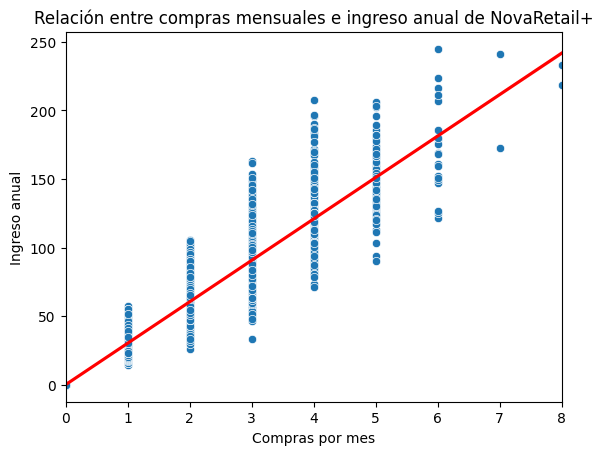

In [7]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
sns.regplot(data=df, x='compras_mes', y='ingreso_anual',
    scatter=False, color='red')
plt.title('Relación entre compras mensuales e ingreso anual de NovaRetail+')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

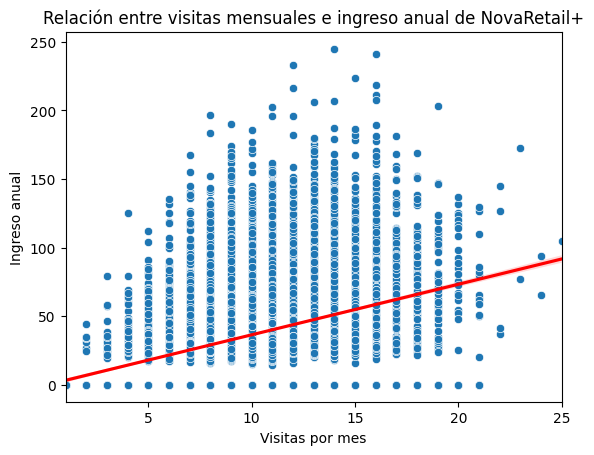

In [8]:
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual')
sns.regplot(data=df, x='visitas_mes', y='ingreso_anual',
    scatter=False, color='red')
plt.title('Relación entre visitas mensuales e ingreso anual de NovaRetail+')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()

✍️ **Comentario**:
Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Dirección: Positiva muy fuerte. Conforme aumenta el número de compras mensuales, también aumenta el ingreso anual.
- Dispersión: Baja. Los puntos se encuentran relativamente cerca de la línea de tendencia, lo que indica una relación lineal consistente.
- Presencia de outliers: Se observan algunos valores con ingresos más altos o más bajos que el resto para un mismo número de compras, pero no parecen ser extremos ni alterar significativamente el patrón general.
- Posible colinealidad: Sí. La relación es muy fuerte (correlación = 0.967), por lo que esta variable podría presentar colinealidad con `ingreso_anual` en un modelo predictivo. Dado que ingreso_anual es la variable objetivo, esto no representa un problema para el análisis exploratorio, pero es un aspecto a considerar en etapas posteriores de modelado.

**ingreso_anual vs visitas_mes**
- Dirección: Positiva. A medida que aumentan las visitas mensuales, el ingreso anual tiende a incrementarse.
- Dispersión: Alta. Los puntos están bastante dispersos alrededor de la línea de tendencia, lo que indica que la relación es moderada y existen otros factores que influyen en el ingreso anual.
- Presencia de outliers: Se observan algunos clientes con ingresos considerablemente superiores o inferiores al resto para un mismo número de visitas, aunque no parecen ser valores extremadamente atípicos.
- Posible colinealidad: No. La correlación (0.337) es moderada, por lo que no existe evidencia de una colinealidad fuerte entre estas variables.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [12]:
# Calcular correlación entre variables relevantes
df['ingreso_anual'].corr(df['compras_mes'], method='pearson')

0.9671485435708566

In [13]:
df['ingreso_anual'].corr(df['compras_mes'], method='spearman')

0.9674824920326731

In [10]:
# Calcular correlación entre variables relevantes
df['ingreso_anual'].corr(df['visitas_mes'], method='spearman')

0.3209536973769648

In [14]:
df['ingreso_anual'].corr(df['visitas_mes'], method='pearson')

0.33714664324987453

✍️ **Comentario**:
Observaciones de correlación

**ingreso_anual vs compras_mes**
- La relación entre `compras_mes` e `ingreso_anual` presenta coeficientes muy similares para Pearson (0.9671) y Spearman (0.9675). Esto indica una asociación positiva muy fuerte, tanto en términos lineales como monotónicos. Además, confirma lo observado en el scatterplot, donde los datos siguen claramente una tendencia ascendente con poca dispersión.

**ingreso_anual vs visitas_mes** 
- En el caso de `visitas_mes` e `ingreso_anual`, los coeficientes de Pearson (0.3371) y Spearman (0.3209) muestran una correlación positiva moderada. La similitud entre ambos valores indica que la relación es consistente, aunque considerablemente más débil que la existente con el número de compras. Esto coincide con el scatterplot, donde se observa una mayor dispersión de los datos alrededor de la línea de tendencia.

- Los coeficientes de Pearson y Spearman respaldan los hallazgos del análisis exploratorio. La variable `compras_mes` es la que presenta la relación más fuerte con `ingreso_anual`, por lo que constituye el principal indicador del ingreso generado por los clientes. En contraste, `visitas_mes` también mantiene una asociación positiva con el ingreso anual, aunque su capacidad explicativa es menor debido a la mayor variabilidad observada.

- La similitud entre los coeficientes de Pearson y Spearman en ambas relaciones sugiere que los resultados son consistentes y que no existen diferencias importantes entre la asociación lineal y la asociación monotónica de las variables analizadas.

### Punto-biserial

In [19]:
from scipy.stats import pointbiserialr
# Calcular la correlación punto-biserial
pointbiserialr(df["miembro_premium"], df["ingreso_anual"])


SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [20]:
pointbiserialr(df["abandono"], df["ingreso_anual"])

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

✍️ **Comentario**:
Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- La variable `miembro_premium` presenta una correlación positiva muy débil con ingreso_anual (r = 0.0931). Aunque el coeficiente es pequeño, el p-valor es menor a 0.001, lo que indica que la relación es estadísticamente significativa. Esto sugiere que los clientes con membresía premium tienden a generar un ingreso anual ligeramente mayor; sin embargo, el efecto es reducido.

**abandono vs ingreso_anual**
- En contraste, la variable `abandono` muestra una correlación prácticamente nula con ingreso_anual (r= -0.0028). Además, el p-valor (0.7295) es mayor a 0.05, por lo que no existe evidencia estadística suficiente para afirmar que el abandono esté relacionado con el ingreso anual.


-La correlación punto-biserial confirma que las variables binarias tienen una influencia limitada sobre el ingreso anual. Mientras que `miembro_premium` presenta una asociación positiva muy débil, `abandono` no muestra una relación estadísticamente significativa. En comparación con `compras_mes`, cuya correlación con `ingreso_anual` fue de 0.967, las variables binarias aportan mucha menos información para explicar el comportamiento del ingreso anual.

### V de Cramér

In [30]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()

    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print("Tabla de contingencia: Tipo de dispositivo vs Abandono")
display(pd.crosstab(df['tipo_dispositivo'], df['abandono']))

print("\nTabla de contingencia: Región vs Miembro premium")
display(pd.crosstab(df['region'], df['miembro_premium']))

Tabla de contingencia: Tipo de dispositivo vs Abandono


abandono,0,1
tipo_dispositivo,,
escritorio,3149,571
móvil,8356,1462
tablet,1234,228



Tabla de contingencia: Región vs Miembro premium


miembro_premium,0,1
region,,
este,2647,422
norte,3801,594
oeste,3283,527
sur,3180,546


In [31]:
# Aplicar V de Cramér en variables relevantes
# Tipo de dispositivo vs abandono
cv_dispositivo_abandono = cramers_v(df['tipo_dispositivo'], df['abandono'])

# Región vs miembro premium
cv_region_premium = cramers_v(df['region'], df['miembro_premium'])

print(f"V de Cramer (tipo_dispositivo vs abandono): {cv_dispositivo_abandono:.4f}")
print(f"V de Cramer (region vs miembro_premium): {cv_region_premium:.4f}")


V de Cramer (tipo_dispositivo vs abandono): 0.0072
V de Cramer (region vs miembro_premium): 0.0126


✍️ **Comentario**: 
Observaciones V de Cramér:
- Como primer paso, se decidió incluir las variables binarias "miembro_premium" y "abandono" como variables categóricas, debido a que en nuestro dataset solo tenemos dos variables categóricas como tal ("tipo_dispositivo" y "region") que no vale la pena analizar mediante una correlación, por lo que se hizo el análisis siguiente:
- La asociación entre "tipo_dispositivo" y "abandono" obtuvo una V de Cramer de 0.0072, lo que indica una asociación prácticamente inexistente. Esto sugiere que el tipo de dispositivo utilizado por los clientes no está relacionado con la probabilidad de abandonar la plataforma.
- En el caso de "region" y "miembro_premium", la V de Cramer fue de 0.0126, lo que también representa una asociación prácticamente nula. Por lo tanto, no se observa evidencia de que la región geográfica influya en la pertenencia al programa de membresía premium.


## Sección 5 - Interpretación de resultados para el negocio

---

✍️ **Hallazgos**:

### Hallazgo 1 — El número de compras mensuales es la variable más asociada con el ingreso anual.

**Evidencia visual:**  Matriz de correlación.
 Scatterplot compras_mes vs ingreso_anual. 

**Evidencia numérica:** Correlación de Pearson: 0.9671
Correlación de Spearman: 0.9675

**Interpretación**  
Existe una asociación positiva muy fuerte entre el número de compras realizadas por un cliente y el ingreso anual generado. En general, los clientes que realizan más compras también tienden a generar mayores ingresos para la empresa.

**No podemos afirmar** que incrementar el número de compras por sí solo cause un aumento en el ingreso anual, ya que este análisis únicamente identifica asociaciones y no relaciones de causa-efecto.

**Implicación de negocio**  
Las estrategias enfocadas en incrementar la frecuencia de compra (programas de fidelización, promociones o recomendaciones personalizadas) podrían estar relacionadas con mayores ingresos y merecen ser analizadas con mayor profundidad.

### Hallazgo 2 — Las visitas a la plataforma muestran una relación positiva, pero mucho más débil con el ingreso anual.

**Evidencia visual:** Scatterplot visitas_mes vs ingreso_anual.   
**Evidencia numérica:** Correlación de Pearson: 0.3371
 Correlación de Spearman: 0.3209

**Interpretación**  
Los clientes que visitan con mayor frecuencia la plataforma tienden a generar mayores ingresos; sin embargo, la relación es moderada y presenta una mayor dispersión que la observada con el número de compras.

**No podemos afirmar** que aumentar las visitas genere automáticamente un incremento en el ingreso anual, ya que otros factores podrían influir en esta relación.

**Implicación de negocio**  
No basta con atraer más visitas; también es importante implementar estrategias que conviertan esas visitas en compras efectivas, ya que las compras muestran una asociación mucho más fuerte con el ingreso.

### Hallazgo 3 — La membresía premium presenta una relación muy débil con el ingreso anual.
  
**Evidencia numérica:** Correlación punto-biserial: r = 0.0931.
  p < 0.001

**Interpretación**  
Existe una relación positiva muy débil entre ser miembro premium y el ingreso anual. Aunque la asociación es estadísticamente significativa, su magnitud es reducida.

**No podemos afirmar** que convertir a un cliente en miembro premium aumente su ingreso anual, ya que la relación observada es muy débil y este análisis no permite establecer causalidad.

**Implicación de negocio**
La membresía premium, por sí sola, no parece ser un factor determinante del ingreso anual. Sería recomendable analizar otros aspectos del comportamiento de los clientes premium, como su frecuencia de compra o su permanencia en la plataforma.

### Hallazgo 4 - No se encontraron asociaciones relevantes entre las variables categóricas analizadas.

**Evidencia numérica:**
Tipo de dispositivo vs abandono: V = 0.0072
Región vs miembro premium: V = 0.0126

**Interpretación** 
Las asociaciones entre las variables categóricas analizadas son prácticamente inexistentes, lo que indica que estas variables se comportan de manera independiente dentro del conjunto de datos.

**No podemos afirmar que** el tipo de dispositivo influya en el abandono, ni que la región determine la pertenencia al programa premium, ya que no se observó una asociación relevante.

**Implicación de negocio**
Con la información disponible, no sería prioritario diseñar estrategias diferenciadas según el dispositivo utilizado o la región geográfica. Podría ser más útil enfocar los esfuerzos en variables relacionadas con el comportamiento de compra.


## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**:


### **Limitaciones**
- Correlación ≠ causalidad. Las asociaciones identificadas no permiten concluir que una variable cause cambios en otra; únicamente indican que existe (o no) una relación estadística entre ellas.
- El análisis se basa únicamente en las variables disponibles en el conjunto de datos. Es posible que existan otros factores no considerados (por ejemplo, campañas promocionales, historial de compras, estacionalidad o características del cliente) que también influyan en el ingreso anual.
- Las relaciones evaluadas fueron principalmente lineales o monotónicas. Podrían existir relaciones más complejas que no se detectan mediante correlaciones y que requerirían modelos estadísticos o de aprendizaje automático.
- Los resultados corresponden a este conjunto de datos específico. Antes de implementar decisiones de negocio, sería recomendable validar los hallazgos con información adicional o datos de distintos periodos.
  
### **Próximos pasos** 
1. Probar segmentación adicional:
- Analizar el comportamiento de compra por rangos de edad para identificar si ciertos grupos generan mayores ingresos.
- Segmentar a los clientes por nivel de ingreso o por frecuencia de compras para detectar perfiles de mayor valor para la empresa.

2. Profundizar en el análisis del comportamiento de compra:
Investigar qué factores influyen en que un cliente realice más compras, por ejemplo, la satisfacción, el gasto en publicidad dirigida o la membresía premium.

3. Desarrollar modelos predictivos:
Construir un modelo de regresión o de aprendizaje automático para predecir el ingreso anual e identificar cuáles variables tienen mayor capacidad predictiva cuando se analizan de forma conjunta.
